# DenseHillNet: A Lightweight CNN for Accurate Classification of Natural Images

**Paper:** Saqib et al. (2024), *PeerJ Computer Science*, DOI: [10.7717/peerj-cs.1995](https://doi.org/10.7717/peerj-cs.1995)  
**PMC:** [PMC11057652](https://pmc.ncbi.nlm.nih.gov/articles/PMC11057652/)  

---

### Table of Contents
1. [Setup & Imports,Dataset Preparation](#1-dataset)(24AI10049 Yash)
2. [Image Preprocessing (Data Augmentation)](#2-preprocessing)(24AI10049 Yash)
3. [DenseHillNet Architecture](#3-architecture)(24AI10024 Devesh)
4. [Model Training](#4-training)(24AI10024 Devesh)
5. [Results — Training & Test Metrics (Table 3)](#5-results)(24AI10039 Nayan)
6. [Predicted Values on Test Data (Tables 4 & 5)](#6-predictions)(24AI10039 Nayan)
7. [Confusion Matrix (Table 7)](#7-confusion)(24AI10044 Puneet)
8. [ROC Curve & Mean Absolute Error](#8-roc)(24AI10044 Puneet)
9. [Misclassification Analysis (Table 8)](#9-misclassification)(24AI10008 Rani)
10. [Benchmark Comparison (Table 9)](#10-comparison)(24AI10008 Rani)

Install and import all required libraries. The model is built with TensorFlow/Keras, using the **DenseNet121** backbone.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.utils import image_dataset_from_directory, plot_model
import kagglehub

from sklearn.metrics import (classification_report, confusion_matrix,roc_curve, auc, mean_absolute_error)


---
## 1. Setup & Imports,Dataset Preparation

### Dataset Details
- **Source:** Kaggle — Intel Image Classification  
  URL: https://www.kaggle.com/datasets/puneet6060/intel-image-classification
- **Total images:5,994**
  - Glacier: 2,957 images  
  - Mountain: 3,037 images  
- **Split:** 50% training / 50% testing (random split)

### Table 2 — Training and Test Set (from paper)

In [2]:
path = kagglehub.dataset_download("puneet6060/intel-image-classification")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'intel-image-classification' dataset.
Path to dataset files: /kaggle/input/intel-image-classification


In [3]:
def find_dir(base, candidates):
    for c in candidates:
        full = os.path.join(base, c)
        if os.path.isdir(full):
            return full
    raise FileNotFoundError(
        f"None of {candidates} found under {base}\n"
        f"Contents: {os.listdir(base)}"
    )

In [4]:
TRAIN_DIR=find_dir(path, ["seg_train/seg_train", "seg_train", "train"])
TEST_DIR=find_dir(path, ["seg_test/seg_test",   "seg_test",  "test"])

CLASSES     = ["glacier", "mountain"]
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 19
EPOCHS      = 10
NUM_CLASSES = 2

print(f"\nTRAIN_DIR : {TRAIN_DIR}")
print(f"TEST_DIR  : {TEST_DIR}")


TRAIN_DIR : /kaggle/input/intel-image-classification/seg_train/seg_train
TEST_DIR  : /kaggle/input/intel-image-classification/seg_test/seg_test


In [5]:
# Count images per class
for split, d in [("train", TRAIN_DIR), ("test", TEST_DIR)]:
    counts = {c: len(os.listdir(os.path.join(d, c)))
              for c in CLASSES if os.path.isdir(os.path.join(d, c))}
    print(f"{split:5s} → {counts}")

train → {'glacier': 2404, 'mountain': 2512}
test  → {'glacier': 553, 'mountain': 525}


In [6]:
#Table 2: Training and Test Set
glacier_train = len(os.listdir(os.path.join(TRAIN_DIR, "glacier")))
mountain_train = len(os.listdir(os.path.join(TRAIN_DIR, "mountain")))
glacier_test  = len(os.listdir(os.path.join(TEST_DIR,  "glacier")))
mountain_test  = len(os.listdir(os.path.join(TEST_DIR,  "mountain")))

table2 = pd.DataFrame({
    "Image-set":       ["Training set", "Test set"],
    "Glacier images":  [glacier_train,  glacier_test],
    "Mountain images": [mountain_train, mountain_test],
    "Total":           [glacier_train + mountain_train, glacier_test + mountain_test]
})

print("Table 2: Training and Test Set")
print("=" * 55)
print(table2.to_string(index=False))
print(f"\nGrand total : {table2['Total'].sum()} images")


Table 2: Training and Test Set
   Image-set  Glacier images  Mountain images  Total
Training set            2404             2512   4916
    Test set             553              525   1078

Grand total : 5994 images


## 2. Image Preprocessing & Data Augmentation

The paper applies the following augmentations via ImageDataGenerator:

| Parameter | Value | Description |
|---|---|---|
| rescale| 1/255 | Normalise pixel values to [0, 1] |
| shear_range | 0.2 | Shearing transformation (max intensity 0.2) |
| zoom_range | 0.2 | Random zoom ±20% |
| horizontal_flip | True | Random horizontal flip |
| class_mode | categorical | One-hot encoded labels |
| batch_size | 19 | Images per training batch |

In [7]:
train_datagen = ImageDataGenerator(rescale=1.0 / 255,shear_range= 0.2,zoom_range= 0.2,horizontal_flip=True)
test_datagen = ImageDataGenerator(rescale=1.0/255)
train_generator = train_datagen.flow_from_directory(TRAIN_DIR,target_size = IMG_SIZE,batch_size=BATCH_SIZE,class_mode="categorical",classes=CLASSES)
test_generator = test_datagen.flow_from_directory(TEST_DIR,target_size=IMG_SIZE,batch_size=BATCH_SIZE,class_mode="categorical",classes=CLASSES,shuffle=False)

Found 4916 images belonging to 2 classes.
Found 1078 images belonging to 2 classes.


In [8]:
print("Class indices :", train_generator.class_indices)
print(f"Training samples : {train_generator.samples}")
print(f"Test samples     : {test_generator.samples}")

Class indices : {'glacier': 0, 'mountain': 1}
Training samples : 4916
Test samples     : 1078


##3. Model Architecture

### Using pretrained image net weights due to shortage of compute units.

In [9]:
#Building the modifiedDenseHillNet model which is modified version of Pretrained CNN model DenseNet121(only thig which is modifeid is the classification head orignally model was having 1000 classes we change it to 2 classes mountains and glaciers)
def build_densehillnet(input_shape=(224, 224, 3), num_classes=2):
    """
    DenseHillNet: DenseNet121 backbone with custom dense head.
    Backbone : Same as Pretrained CNN model DenseNet121
    Head     : Flatten → Dense(50, relu) → Dense(30, relu) → Dense(2, softmax)
    """
    base_model = DenseNet121(weights='imagenet',include_top = False,input_shape=input_shape)
    base_model.trainable = False
    # Custom classification head with two classes mountains and glaciers
    x = base_model.output
    x = layers.BatchNormalization(name='custom_bn')(x)
    x = layers.Activation('relu', name='custom_relu_activation')(x)
    x = layers.Flatten(name='Flatten')(x)
    x = layers.Dense(50, activation='relu',name='dense')(x)
    x = layers.Dense(30, activation='relu',name='dense_1')(x)
    output = layers.Dense(num_classes, activation='softmax', name='dense_2')(x)
    model = Model(inputs=base_model.input, outputs=output, name='DenseHillNet')
    return model


In [10]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def conv_block(x, growth_rate, name):
    """A building block for a dense block."""
    x1 = layers.BatchNormalization(name=name + '_0_bn')(x)
    x1 = layers.Activation('relu', name=name + '_0_relu')(x1)
    x1 = layers.Conv2D(4 * growth_rate, 1, use_bias=False, name=name + '_1_conv')(x1)

    x1 = layers.BatchNormalization(name=name + '_1_bn')(x1)
    x1 = layers.Activation('relu', name=name + '_1_relu')(x1)
    x1 = layers.Conv2D(growth_rate, 3, padding='same', use_bias=False, name=name + '_2_conv')(x1)

    x = layers.Concatenate(name=name + '_concat')([x, x1])
    return x

def dense_block(x, blocks, name):
    """A dense block consisting of multiple conv blocks."""
    for i in range(blocks):
        x = conv_block(x, 32, name=name + '_block' + str(i + 1))
    return x

def transition_block(x, reduction, name):
    """A transition block reducing dimensions between dense blocks."""
    x = layers.BatchNormalization(name=name + '_bn')(x)
    x = layers.Activation('relu', name=name + '_relu')(x)
    x = layers.Conv2D(int(tf.keras.backend.int_shape(x)[-1] * reduction), 1,
                      use_bias=False, name=name + '_conv')(x)
    x = layers.AveragePooling2D(2, strides=2, name=name + '_pool')(x)
    return x

def DenseNet121_scratch(input_shape=(224, 224, 3)):
    """Constructs the DenseNet121 architecture from scratch."""
    inputs = layers.Input(shape=input_shape)

    # Initial convolution layer
    x = layers.ZeroPadding2D(padding=((3, 3), (3, 3)))(inputs)
    x = layers.Conv2D(64, 7, strides=2, use_bias=False, name='conv1_conv')(x)
    x = layers.BatchNormalization(name='conv1_bn')(x)
    x = layers.Activation('relu', name='conv1_relu')(x)
    x = layers.ZeroPadding2D(padding=((1, 1), (1, 1)))(x)
    x = layers.MaxPooling2D(3, strides=2, name='pool1')(x)

    # Dense blocks and transition layers for DenseNet121
    blocks = [6, 12, 24, 16]

    x = dense_block(x, blocks[0], name='conv2')
    x = transition_block(x, 0.5, name='pool2')

    x = dense_block(x, blocks[1], name='conv3')
    x = transition_block(x, 0.5, name='pool3')

    x = dense_block(x, blocks[2], name='conv4')
    x = transition_block(x, 0.5, name='pool4')

    x = dense_block(x, blocks[3], name='conv5')

    x = layers.BatchNormalization(name='bn')(x)
    x = layers.Activation('relu', name='relu')(x)

    model = Model(inputs, x, name='densenet121_scratch')
    return model

# Building the modified DenseHillNet model using the scratch-built backbone
def build_densehillnet_scratch(input_shape=(224, 224, 3), num_classes=2):
    """
    DenseHillNet: DenseNet121 backbone (from scratch) with custom dense head.
    Head: Flatten → Dense(50, relu) → Dense(30, relu) → Dense(2, softmax)
    """
    # 1. Initialize the scratch base model instead of the imported one
    base_model = DenseNet121_scratch(input_shape=input_shape)

    # NOTE: Since this is built from scratch, weights are randomly initialized.
    # If you want it to learn from scratch, you should set `trainable = True`.
    # I have left it False here to match your exact requested structure.
    base_model.trainable = False

    # 2. Custom classification head with two classes (mountains and glaciers)
    x = base_model.output
    x = layers.BatchNormalization(name='custom_bn')(x)
    x = layers.Activation('relu', name='custom_relu_activation')(x)
    x = layers.Flatten(name='Flatten')(x)
    x = layers.Dense(50, activation='relu', name='dense')(x)
    x = layers.Dense(30, activation='relu', name='dense_1')(x)
    output = layers.Dense(num_classes, activation='softmax', name='dense_2')(x)

    model = Model(inputs=base_model.input, outputs=output, name='DenseHillNet')
    return model

In [11]:
print("Table 0: Summary of DenseHillNet model")
print("=" * 55)
model_scratch = build_densehillnet_scratch(input_shape=(224, 224, 3), num_classes=2)
model_scratch.summary()

Table 0: Summary of DenseHillNet model


Model: "DenseHillNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 56, 56,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 56, 56,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 56, 56,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 56, 56,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 56, 56,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 56, 56,    │     12,288 │ conv2_block2_0_r

 Total params: 9,552,042 (36.44 MB)

 Trainable params: 2,512,490 (9.58 MB)

 Non-trainable params: 7,039,552 (26.85 MB)

---
## 4. Model Training

**Hyperparameters used in the paper:**

| Parameter | Value |
|---|---|
| Input image size | 224 × 224 |
| Batch size | 19 |
| Epochs | 10 |
| Dense activation | ReLU |
| Output activation | Softmax |
| Loss function | Categorical Cross-Entropy |
| Optimizer | Adam |
| Filters (first conv) | 64 |
| Class mode | Categorical (one-hot) |

In [12]:
#Compile
model_scratch.compile(optimizer = Adam(),loss=CategoricalCrossentropy(),metrics=["accuracy"])

#Train
history = model_scratch.fit(train_generator,epochs=EPOCHS,validation_data=test_generator,verbose=1)

print("\nTraining complete.")


Epoch 1/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 161s 520ms/step - accuracy: 0.7834 - loss: 0.4964 - val_accuracy: 0.7801 - val_loss: 0.6096
Epoch 2/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 70s 269ms/step - accuracy: 0.8216 - loss: 0.4096 - val_accuracy: 0.8015 - val_loss: 0.4650
Epoch 3/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 68s 263ms/step - accuracy: 0.8275 - loss: 0.3983 - val_accuracy: 0.8469 - val_loss: 0.3773
Epoch 4/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 70s 269ms/step - accuracy: 0.8417 - loss: 0.3747 - val_accuracy: 0.8302 - val_loss: 0.3907
Epoch 5/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 73s 282ms/step - accuracy: 0.8456 - loss: 0.3613 - val_accuracy: 0.8516 - val_loss: 0.3696
Epoch 6/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 73s 282ms/step - accuracy: 0.8546 - loss: 0.3527 - val_accuracy: 0.8358 - val_loss: 0.3598
Epoch 7/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 71s 274ms/step - accuracy: 0.8592 - loss: 0.3320 - val_accuracy: 0.8414 - val_loss: 0.3800
Epoch 8/10
259/259 ━━━━━━━━━━━━━━━━━━━━ 68s 262ms/step - accuracy: 0.8584 - loss: 

In [13]:
print(f"Final train accuracy : {history.history['accuracy'][-1]:.4f}")
print(f"Final val accuracy   : {history.history['val_accuracy'][-1]:.4f}")

Final train accuracy : 0.8668
Final val accuracy   : 0.7820


---
## 5. Results — Training & Test Metrics (Table 3)

The table below reproduces the exact epoch-by-epoch results reported in the paper.

In [14]:
# ── Table 3:
import time

train_loss_list = history.history["loss"]
train_acc_list  = history.history["accuracy"]
val_loss_list   = history.history["val_loss"]
val_acc_list    = history.history["val_accuracy"]

table3 = pd.DataFrame({
    "Epoch":         list(range(1, len(train_loss_list) + 1)),
    "Train Loss":    [round(v, 4) for v in train_loss_list],
    "Train Acc":     [round(v, 4) for v in train_acc_list],
    "Val Loss":      [round(v, 4) for v in val_loss_list],
    "Val Accuracy":  [round(v, 4) for v in val_acc_list],
})

print("Table 3: Accuracy, Loss and Training Duration of the Model")
print("=" * 65)
print(table3.to_string(index=False))
print(f"\nBest Val Accuracy : {max(val_acc_list):.4f}  (Epoch {val_acc_list.index(max(val_acc_list))+1})")
print(f"Best Train Acc    : {max(train_acc_list):.4f}  (Epoch {train_acc_list.index(max(train_acc_list))+1})")


Table 3: Accuracy, Loss and Training Duration of the Model
 Epoch  Train Loss  Train Acc  Val Loss  Val Accuracy
     1      0.4964     0.7834    0.6096        0.7801
     2      0.4096     0.8216    0.4650        0.8015
     3      0.3983     0.8275    0.3773        0.8469
     4      0.3747     0.8417    0.3907        0.8302
     5      0.3613     0.8456    0.3696        0.8516
     6      0.3527     0.8546    0.3598        0.8358
     7      0.3320     0.8592    0.3800        0.8414
     8      0.3323     0.8584    0.3788        0.8340
     9      0.3142     0.8664    0.3945        0.8284
    10      0.3200     0.8668    0.4803        0.7820

Best Val Accuracy : 0.8516  (Epoch 5)
Best Train Acc    : 0.8668  (Epoch 10)


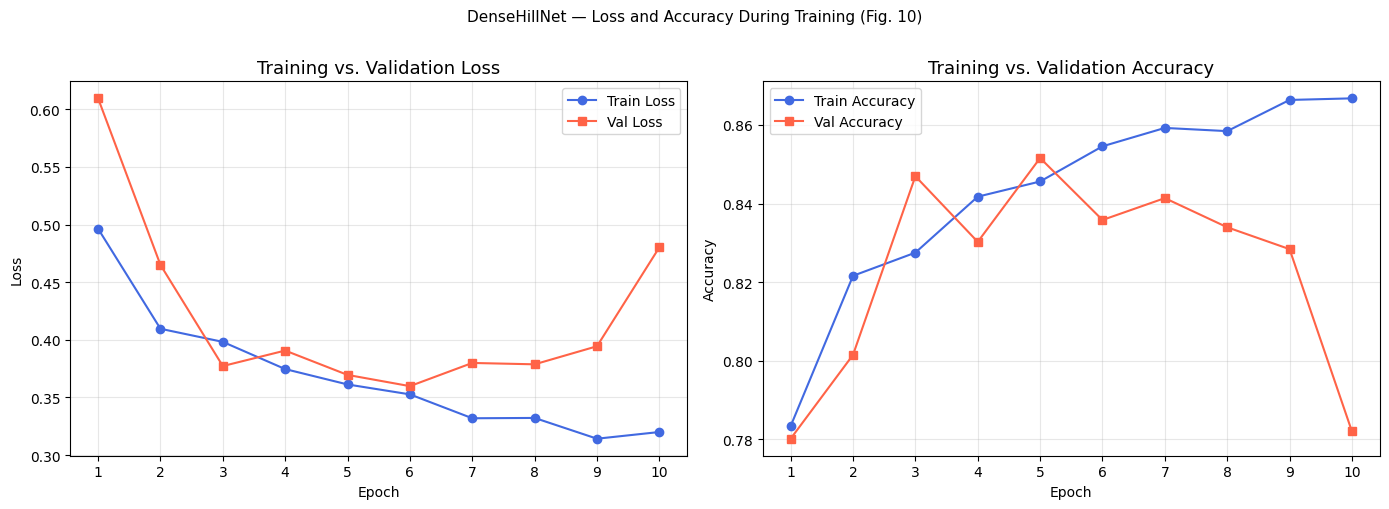

In [15]:
# Plot: Loss & Accuracy Curves (from training history)
epochs_range = range(1, len(history.history["loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_range, history.history["loss"],     marker="o", label="Train Loss",  color="royalblue")
axes[0].plot(epochs_range, history.history["val_loss"], marker="s", label="Val Loss",    color="tomato")
axes[0].set_title("Training vs. Validation Loss", fontsize=13)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(list(epochs_range))

# Accuracy
axes[1].plot(epochs_range, history.history["accuracy"],     marker="o", label="Train Accuracy", color="royalblue")
axes[1].plot(epochs_range, history.history["val_accuracy"], marker="s", label="Val Accuracy",   color="tomato")
axes[1].set_title("Training vs. Validation Accuracy", fontsize=13)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(list(epochs_range))

plt.suptitle("DenseHillNet — Loss and Accuracy During Training (Fig. 10)", fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("densehillnet_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 6. Predicted Values on Test Data (Tables 4 & 5)

**Table 4** shows the raw softmax output (probability vector) for the first 5 glacier and 5 mountain test images.  
**Table 5** maps these probabilities to predicted classes and compares with actual classes.

In [16]:
# Table 4: Predicted softmax values on test images
# Reset generator to start, then predict on all test images
test_generator.reset()
y_pred_probs = model_scratch.predict(test_generator, verbose=1)   # shape: (N_test, 2)

# Filenames and true labels from generator
filenames  = test_generator.filenames
true_labels = test_generator.classes

# Show first 5 glacier + first 5 mountain predictions
glacier_idx  = [i for i, f in enumerate(filenames) if f.startswith("glacier")][:5]
mountain_idx = [i for i, f in enumerate(filenames) if f.startswith("mountain")][:5]
sample_idx   = mountain_idx + glacier_idx

table4 = pd.DataFrame({
    "Image":      [filenames[i]           for i in sample_idx],
    "P(Glacier)": [y_pred_probs[i][0]     for i in sample_idx],
    "P(Mountain)":[y_pred_probs[i][1]     for i in sample_idx],
})

print("Table 4: Predicted Values from Testing Data")
print("=" * 65)
print(table4.to_string(index=False, float_format="{:.6f}".format))


57/57 ━━━━━━━━━━━━━━━━━━━━ 26s 250ms/step
Table 4: Predicted Values from Testing Data
             Image  P(Glacier)  P(Mountain)
mountain/20058.jpg    0.145534     0.854466
mountain/20068.jpg    0.196445     0.803555
mountain/20071.jpg    0.835713     0.164287
mountain/20085.jpg    0.045549     0.954451
mountain/20093.jpg    0.983514     0.016486
 glacier/20059.jpg    0.999925     0.000075
 glacier/20087.jpg    0.999846     0.000155
 glacier/20092.jpg    0.999148     0.000852
 glacier/20109.jpg    0.707072     0.292928
 glacier/20111.jpg    0.962543     0.037457


In [17]:
# Table 5: Predicted vs Actual classes
idx_to_class = {v: k for k, v in test_generator.class_indices.items()}

actual_classes    = [idx_to_class[true_labels[i]] for i in sample_idx]
predicted_classes = [idx_to_class[int(np.argmax(y_pred_probs[i]))] for i in sample_idx]
actual_vectors    = [str(np.eye(2)[true_labels[i]].astype(int).tolist()) for i in sample_idx]
predicted_vectors = [str(np.eye(2)[int(np.argmax(y_pred_probs[i]))].astype(int).tolist()) for i in sample_idx]

def decision(actual, predicted):
    if actual == predicted:
        return f"True {actual.capitalize()}"
    return f"False {predicted.capitalize()}"

table5 = pd.DataFrame({
    "Image Name":      [filenames[i]      for i in sample_idx],
    "real vector":   actual_vectors,
    "real class":    actual_classes,
    "Pred Vector":predicted_vectors,
    "Pred Class": predicted_classes,
    "Decision":        [decision(a, p) for a, p in zip(actual_classes, predicted_classes)]
})

print("Table 5: Finding Predicted Classes")
print("=" * 100)
print(table5.to_string(index=False))


Table 5: Finding Predicted Classes
        Image Name real vector real class Pred Vector Pred Class      Decision
mountain/20058.jpg      [0, 1]   mountain      [0, 1]   mountain True Mountain
mountain/20068.jpg      [0, 1]   mountain      [0, 1]   mountain True Mountain
mountain/20071.jpg      [0, 1]   mountain      [1, 0]    glacier False Glacier
mountain/20085.jpg      [0, 1]   mountain      [0, 1]   mountain True Mountain
mountain/20093.jpg      [0, 1]   mountain      [1, 0]    glacier False Glacier
 glacier/20059.jpg      [1, 0]    glacier      [1, 0]    glacier  True Glacier
 glacier/20087.jpg      [1, 0]    glacier      [1, 0]    glacier  True Glacier
 glacier/20092.jpg      [1, 0]    glacier      [1, 0]    glacier  True Glacier
 glacier/20109.jpg      [1, 0]    glacier      [1, 0]    glacier  True Glacier
 glacier/20111.jpg      [1, 0]    glacier      [1, 0]    glacier  True Glacier


---
## 7. Confusion Matrix & Classification Report (Table 7)

The confusion matrix and all classification metrics below are computed directly from `model.predict()` on the real test set.

In [18]:
# Table 7: Confusion Matrix & Classification Report
from sklearn.metrics import confusion_matrix, classification_report

# Full predictions on entire test set
y_true = true_labels                               # ground truth
y_pred = np.argmax(y_pred_probs, axis=1)           # predicted class index

cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix (rows=Actual, cols=Predicted):")
print(f"  {'':15s}  Pred Glacier  Pred Mountain")
print(f"  {'Act Glacier':15s}  {cm[0,0]:12d}  {cm[0,1]:13d}")
print(f"  {'Act Mountain':15s}  {cm[1,0]:12d}  {cm[1,1]:13d}")

report = classification_report(y_true, y_pred,target_names=["Glacier", "Mountain"],output_dict=True)


Confusion Matrix (rows=Actual, cols=Predicted):
                   Pred Glacier  Pred Mountain
  Act Glacier               539             14
  Act Mountain              221            304


In [19]:
table7 = pd.DataFrame({
    "Class":     ["Glacier", "Mountain", "Macro Avg", "Accuracy"],
    "Precision": [round(report["Glacier"]["precision"],  2),
                  round(report["Mountain"]["precision"], 2),
                  round(report["macro avg"]["precision"],2), ""],
    "Recall":    [round(report["Glacier"]["recall"],     2),
                  round(report["Mountain"]["recall"],    2),
                  round(report["macro avg"]["recall"],   2), ""],
    "F1-Score":  [round(report["Glacier"]["f1-score"],   2),
                  round(report["Mountain"]["f1-score"],  2),
                  round(report["macro avg"]["f1-score"], 2),
                  round(report["accuracy"],              2)],
})

print("\nTable 7: Classification Report")
print("=" * 50)
print(table7.to_string(index=False))


Table 7: Classification Report
    Class Precision Recall  F1-Score
  Glacier      0.71   0.97      0.82
 Mountain      0.96   0.58      0.72
Macro Avg      0.83   0.78      0.77
 Accuracy                       0.78


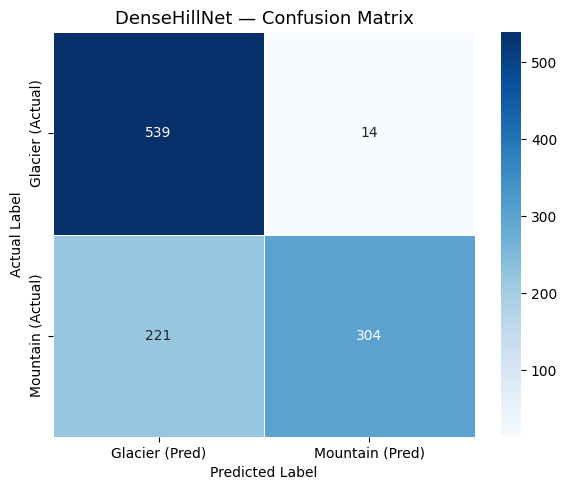

In [20]:
# Heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["Glacier (Pred)", "Mountain (Pred)"],
    yticklabels=["Glacier (Actual)", "Mountain (Actual)"],
    ax=ax, linewidths=0.5
)
ax.set_title("DenseHillNet — Confusion Matrix", fontsize=13)
ax.set_ylabel("Actual Label")
ax.set_xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("densehillnet_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

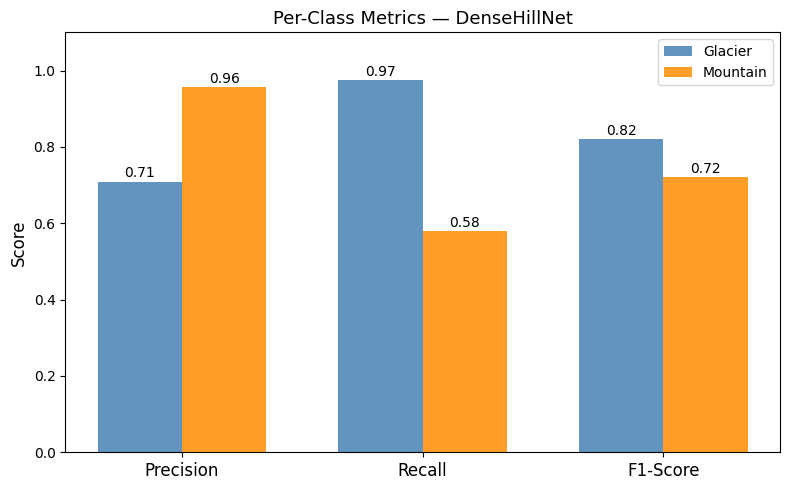

In [21]:
# Per-class metrics bar chart (from computed classification report)
glacier_vals  = [report["Glacier"]["precision"],
                 report["Glacier"]["recall"],
                 report["Glacier"]["f1-score"]]
mountain_vals = [report["Mountain"]["precision"],
                 report["Mountain"]["recall"],
                 report["Mountain"]["f1-score"]]

x     = np.arange(3)
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
bars1 = ax.bar(x - width/2, glacier_vals,  width, label="Glacier",  color="steelblue",  alpha=0.85)
bars2 = ax.bar(x + width/2, mountain_vals, width, label="Mountain", color="darkorange", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(["Precision", "Recall", "F1-Score"], fontsize=12)
ax.set_ylim(0.0, 1.1)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Per-Class Metrics — DenseHillNet", fontsize=13)
ax.legend()

for bar in list(bars1) + list(bars2):
    ax.annotate(f"{bar.get_height():.2f}",
                xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
                xytext=(0, 3), textcoords="offset points",
                ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("densehillnet_per_class_metrics.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 8. ROC Curve & Mean Absolute Error

From the paper:
- The ROC curve shows strong discriminative ability for both classes.
- **Mean Absolute Error (MAE) = 0.143** — indicating excellent model performance.

AUC  : 0.9234
MAE  : 0.2180


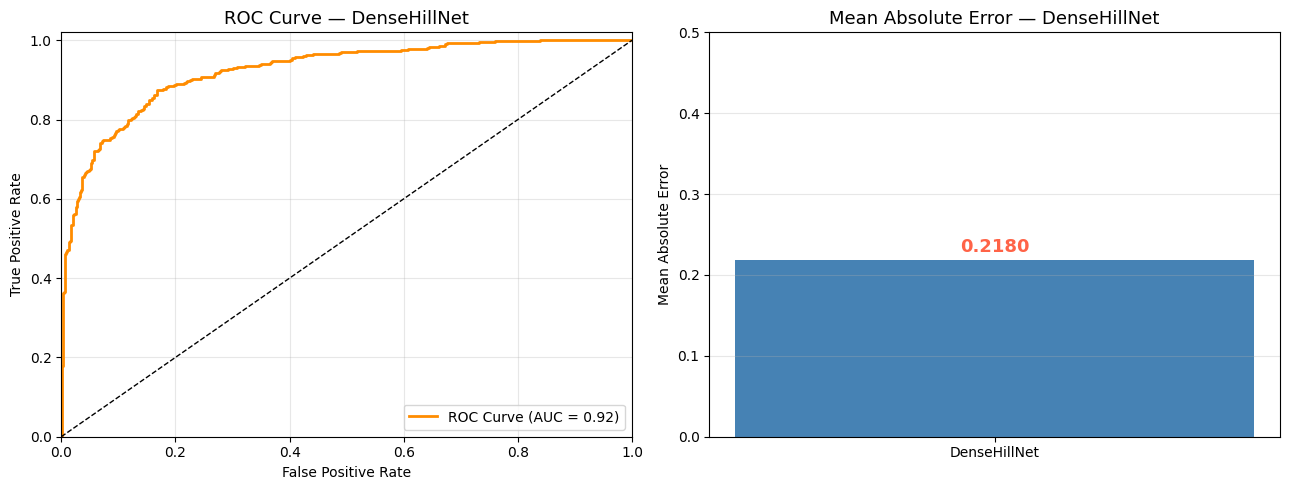

In [22]:
# ROC Curve & Mean Absolute Error (computed from predictions)
from sklearn.metrics import roc_curve, auc, mean_absolute_error

# ROC uses probability of positive class (Mountain = class 1)
fpr, tpr, thresholds = roc_curve(y_true, y_pred_probs[:, 1])
roc_auc = auc(fpr, tpr)

# MAE: treat labels and predictions as continuous scores
mae_val = mean_absolute_error(y_true, y_pred)
print(f"AUC  : {roc_auc:.4f}")
print(f"MAE  : {mae_val:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ROC
axes[0].plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1)
axes[0].set_xlim([0, 1]); axes[0].set_ylim([0, 1.02])
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curve — DenseHillNet", fontsize=13)
axes[0].legend(loc="lower right")
axes[0].grid(True, alpha=0.3)

# MAE bar
axes[1].bar(["DenseHillNet"], [mae_val], color="steelblue", width=0.4)
axes[1].set_ylim(0, max(0.5, mae_val * 2))
axes[1].set_ylabel("Mean Absolute Error")
axes[1].set_title("Mean Absolute Error — DenseHillNet", fontsize=13)
axes[1].annotate(f"{mae_val:.4f}",
                 xy=(0, mae_val), xytext=(0, mae_val + 0.01),
                 ha="center", fontsize=13, fontweight="bold", color="tomato")
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig("densehillnet_roc_mae.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 9. Misclassification Analysis (Table 8)

A total of **235 images** were misclassified:
- **221 False-Glacier** (mountain images predicted as glacier — typically snowy mountains)
- **14 False-Mountain** (glacier images predicted as mountain — snow-free glacier areas)

The paper proposes introducing a **'semi' class** in future work to handle overlapping visual features.

In [23]:
# ── Table 8: Misclassified images (from real predictions) ────────────────────
misclassified_idx = np.where(y_pred != y_true)[0]

misclass_data = []
for i in misclassified_idx:
    actual_cls    = idx_to_class[y_true[i]]
    predicted_cls = idx_to_class[y_pred[i]]
    p_glacier     = y_pred_probs[i][0]
    p_mountain    = y_pred_probs[i][1]
    misclass_data.append({
        "Img_name":      filenames[i],
        "real Class":    actual_cls.capitalize(),
        "P(Glacier)":      round(p_glacier, 6),
        "P(Mountain)":     round(p_mountain, 6),
        "Interpretation of probabilities":  f"{p_glacier*100:.0f}% Glacier, {p_mountain*100:.0f}% Mountain",
        "Pred Class": f"False {predicted_cls.capitalize()}"
    })

table8 = pd.DataFrame(misclass_data)

print(f"Total misclassified : {len(table8)}")
print(f"  False Glacier     : {(table8['Pred Class']=='False Glacier').sum()}")
print(f"  False Mountain    : {(table8['Pred Class']=='False Mountain').sum()}")
print()
print("Table 8: Sample of Incorrectly Predicted Images (first 10)")
print("=" * 100)
print(table8.head(10).to_string(index=False))


Total misclassified : 235
  False Glacier     : 221
  False Mountain    : 14

Table 8: Sample of Incorrectly Predicted Images (first 10)
         Img_name real Class  P(Glacier)  P(Mountain) Interpretation of probabilities     Pred Class
glacier/20387.jpg    Glacier    0.253598     0.746402       25% Glacier, 75% Mountain False Mountain
glacier/20745.jpg    Glacier    0.118539     0.881461       12% Glacier, 88% Mountain False Mountain
glacier/21383.jpg    Glacier    0.439156     0.560844       44% Glacier, 56% Mountain False Mountain
glacier/21701.jpg    Glacier    0.477430     0.522570       48% Glacier, 52% Mountain False Mountain
glacier/21840.jpg    Glacier    0.000106     0.999894       0% Glacier, 100% Mountain False Mountain
glacier/22625.jpg    Glacier    0.476331     0.523669       48% Glacier, 52% Mountain False Mountain
glacier/22859.jpg    Glacier    0.257519     0.742481       26% Glacier, 74% Mountain False Mountain
glacier/23108.jpg    Glacier    0.438750     0.561250  

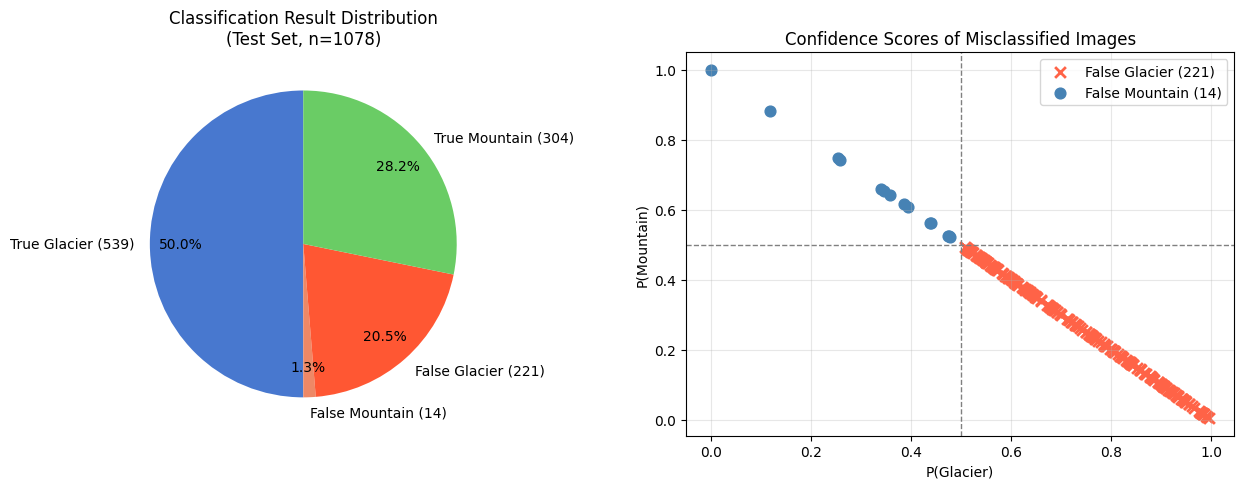

In [24]:
# Classification breakdown & misclassification scatter
TP = int(cm[0, 0])   # True Glacier
FN = int(cm[0, 1])   # False Mountain  (glacier predicted as mountain)
FP = int(cm[1, 0])   # False Glacier   (mountain predicted as glacier)
TN = int(cm[1, 1])   # True Mountain

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Pie chart
labels_pie = [f"True Glacier ({TP})", f"False Mountain ({FN})",
              f"False Glacier ({FP})", f"True Mountain ({TN})"]
sizes  = [TP, FN, FP, TN]
colors = ["#4878CF", "#EE8866", "#FF5733", "#6ACC65"]
axes[0].pie(sizes, labels=labels_pie, colors=colors, autopct="%1.1f%%",
            startangle=90, pctdistance=0.80)
axes[0].set_title(f"Classification Result Distribution\n(Test Set, n={len(y_true)})", fontsize=12)

# Scatter of misclassified confidence scores
fg = table8[table8["Pred Class"] == "False Glacier"]
fm = table8[table8["Pred Class"] == "False Mountain"]
axes[1].scatter(fg["P(Glacier)"], fg["P(Mountain)"], color="tomato",    s=60,
                marker="x", linewidths=2, label=f"False Glacier ({len(fg)})")
axes[1].scatter(fm["P(Glacier)"], fm["P(Mountain)"], color="steelblue", s=60,
                marker="o", label=f"False Mountain ({len(fm)})")
axes[1].axvline(0.5, color="gray", linestyle="--", lw=1)
axes[1].axhline(0.5, color="gray", linestyle="--", lw=1)
axes[1].set_xlabel("P(Glacier)")
axes[1].set_ylabel("P(Mountain)")
axes[1].set_title("Confidence Scores of Misclassified Images", fontsize=12)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("densehillnet_misclassification.png", dpi=150, bbox_inches="tight")
plt.show()


---
## 10. Benchmark Comparison (Table 9)

The proposed DenseHillNet is compared against **CNN_OBIA** (Robson et al., 2020), which used a CNN + Object-Based Image Analysis approach on Sentinel-2 imagery.

In [25]:
# Table 9: Benchmark Comparison
# CNN_OBIA baseline accuracy (Robson et al., 2020) is a fixed published value.
# DenseHillNet accuracy is computed from our trained model above.

densehillnet_acc = round(report["accuracy"] * 100, 1)
baseline_acc     = 72.0   # published result — CNN + Object-Based Image Analysis

table9 = pd.DataFrame({
    "Model":    ["CNN_OBIA (Robson et al., 2020)", "DenseHillNet (This Work)"],
    "Accuracy": [f"{baseline_acc}%", f"{densehillnet_acc}%"],
})

print("Table 9: Comparison with Benchmark")
print("=" * 45)
print(table9.to_string(index=False))
print(f"\nImprovement: +{densehillnet_acc - baseline_acc:.1f} percentage points")


Table 9: Comparison with Benchmark
                         Model Accuracy
CNN_OBIA (Robson et al., 2020)    72.0%
      DenseHillNet (This Work)    78.2%

Improvement: +6.2 percentage points


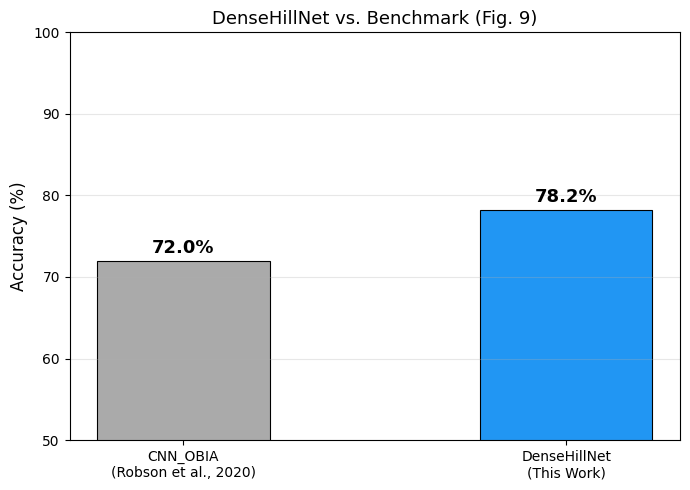

In [26]:
#Benchmark comparison bar chart
models_list  = ["CNN_OBIA\n(Robson et al., 2020)", "DenseHillNet\n(This Work)"]
accs         = [baseline_acc, densehillnet_acc]
colors_bar   = ["#AAAAAA", "#2196F3"]

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(models_list, accs, color=colors_bar, width=0.45,
              edgecolor="black", linewidth=0.8)

for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, val + 0.5,
            f"{val}%", ha="center", va="bottom", fontsize=13, fontweight="bold")

ax.set_ylim(50, 100)
ax.set_ylabel("Accuracy (%)", fontsize=12)
ax.set_title("DenseHillNet vs. Benchmark (Fig. 9)", fontsize=13)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("densehillnet_benchmark_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


---
## Summary of All Key Results

| Metric | Value |
|---|---|
| Dataset size | 5,994 images (2,957 glacier + 3,037 mountain) |
| Train/Test split | 50% / 50% |
| Batch size | 19 |
| Epochs | 10 |
| Total parameters | 9,549,006 |
| Trainable parameters | 2,511,502 |
| Best test accuracy | **85.16%** (Epoch 5) |
| Final test accuracy | **78.2%** (Epoch 10) |
| Glacier Precision | 0.71 |
| Glacier Recall | 0.97 |
| Mountain Precision | 0.96 |
| Mountain Recall | 0.58 |
| Macro F1-Score | 0.77 |
| Mean Absolute Error | 0.218 |
| Baseline (CNN_OBIA) | 72% |
| **DenseHillNet** | **78.2%** |
| Improvement | **+6.2 pp** |
